## Notes

In [168]:
# import os
# import pandas as pd
# import numpy as np

# os.listdir(path)                              # List files in a folder
# [f for f in os.listdir(path) if f.endswith(".csv_files")]  # List csv_files files only

# pd.read_csv_files(path)                             # Read csv_files file
# pd.read_csv_files(path, encoding="cp1252")          # Read csv_files with specified encoding
# pd.read_csv_files(path, usecols=["A", "B"])         # Read selected columns only

# df.dropna()                                   # Remove rows containing missing values
# df.dropna(subset=["Time", "Primary"])         # Remove rows missing selected values
# df.fillna(0)                                  # Replace missing values with 0
# df.isna()                                     # Check missing values
# df.isna().sum()                               # Count missing values per column

# pd.concat([df1, df2])                         # Combine DataFrames vertically
# pd.concat([df1, df2], ignore_index=True)      # Combine and create a new index
# pd.concat([df1, df2], axis=1)                 # Combine DataFrames horizontally

# pd.DataFrame({...})                           # Create a DataFrame
# df.copy()                                     # Create an independent copy

# df.shape                                      # Get (rows, columns)
# len(df)                                       # Get number of rows
# df.size                                       # Get total number of values
# df.head()                                     # Preview first 5 rows
# df.head(10)                                   # Preview first 10 rows
# df.tail()                                     # Preview last 5 rows
# df.sample(5)                                  # Show 5 random rows
# df.info()                                     # Show structure and data types
# df.describe()                                 # Show numerical summary statistics
# df.dtypes                                     # Show data type of every column

# df.columns                                    # View column names
# df.columns.tolist()                           # Convert column names to a list
# df.columns = df.columns.str.strip()           # Remove spaces around column names
# df.rename(columns={"Old": "New"})             # Rename one column
# df.rename(columns={"I1": "Primary", "I2": "Secondary"})  # Rename multiple columns

# df["Col"]                                     # Select one column as a Series
# df[["Col1", "Col2"]]                          # Select multiple columns
# df.loc[:, ["Col1", "Col2"]]                   # Select columns by name
# df.iloc[:, 0]                                 # Select first column by position
# df.iloc[0]                                    # Select first row
# df.iloc[0:5]                                  # Select first 5 rows

# df[df["Trial"] == 1]                          # Filter rows using one condition
# df[(df["Material"] == "Metal") & (df["Trial"] == 1)]  # Filter using multiple conditions
# df[df["Col"].isin(["A", "B"])]                # Keep selected values
# df.query("Trial == 1")                        # Filter using query syntax

# df.sort_values("Col")                         # Sort by one column
# df.sort_values(["Trial", "Time"])             # Sort by multiple columns
# df.sort_values("Col", ascending=False)        # Sort in descending order

# df.reset_index(drop=True)                     # Reset row index
# df.set_index("Time")                          # Set a column as the index

# df["NewCol"] = values                                 # Add or replace a column
# df["Difference"] = df["Primary"] - df["Secondary"]    # Create calculated column
# df.insert(1, "NewCol", values)                        # Insert column at a position
# df.drop(columns=["Col"])                              # Remove a column
# df.drop(index=[0, 1])                                 # Remove selected rows

# df["Col"].unique()                            # Get unique values
# df["Col"].nunique()                           # Count unique values
# df["Col"].value_counts()                      # Count occurrences of each value

# df.groupby("Col")                                                 # Group rows by one column
# df.groupby(["Material", "Trial"])                                 # Group using multiple columns
# df.groupby("Material")["Primary"].mean()                          # Mean Primary for each material
# df.groupby("Trial").agg({"Primary": "mean", "Secondary": "max"})  # Multiple summaries

# df["Col"].to_numpy()                          # Convert Series to NumPy array
# df["Col"].to_numpy(dtype=float)               # Convert to float NumPy array
# df["Col"].tolist()                            # Convert Series to Python list

# df["Col"].astype(float)                       # Convert column to float
# df["Col"].astype(str)                         # Convert column to string
# pd.to_numeric(df["Col"], errors="coerce")     # Convert to numeric; invalid values become NaN

# df["Col"].min()                               # Minimum value
# df["Col"].max()                               # Maximum value
# df["Col"].mean()                              # Mean
# df["Col"].median()                            # Median
# df["Col"].std()                               # Standard deviation
# df["Col"].sum()                               # Sum
# df["Col"].idxmax()                            # Index of maximum value
# df["Col"].idxmin()                            # Index of minimum value

# df.duplicated()                               # Check duplicate rows
# df.drop_duplicates()                          # Remove duplicate rows

# df.replace([np.inf, -np.inf], np.nan)         # Replace infinities with NaN
# df.loc[mask]                                  # Select rows using a Boolean mask

# df.to_csv_files("output.csv_files", index=False)          # Save DataFrame to csv_files
# df.to_excel("output.xlsx", index=False)       # Save DataFrame to Excel

# pd.set_option("display.max_columns", None)     # Display all columns
# pd.set_option("display.max_rows", None)        # Display all rows
# pd.reset_option("display.max_columns")         # Reset column display setting
# pd.reset_option("display.max_rows")            # Reset row display setting

# Sensor Data Exploration
This notebook provides a concise workflow for exploring multiple sensor datasets with pandas. It covers:

- Loading sensor files (csv_files/JSON) and combining them into a single DataFrame.
- Parsing and aligning timestamps, setting a DATEtime index.
- Cleaning steps: handling missing values, duplicates, outliers, and unit/column harmonization.
- Quick descriptive statistics, group summaries by sensor/type, and checks for data quality.
- Time-series operations: resampling, rolling aggregates, and interpolation to common frequencies.
- Visualizations: time series plots, distributions, correlation matrices, and simple anomaly detection.
- Exporting cleaned datasets and prepared features for downstream modeling or reporting.

Expected inputs: one or more files containing timestamp, sensor_id (or similar), and measurement columns.  
Outputs: a cleaned, merged DataFrame, summary tables, and plots to guide further analysis.

In [2]:
import pandas as pd
import numpy as np
import os
import itertools
import math
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.integrate import trapezoid
#from scipy.stats import linregress
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from tsfresh import extract_features
from reservoirpy.nodes import Reservoir

In [3]:
data_path = '../data/Raw-0624/'
#files = os.listdir(f"{data_path}/raw/")
files = os.listdir(f"{data_path}")
files

['I_V-t Sampling [(28) ; 2026_06_24 17_04_26].csv_files',
 'I_V-t Sampling [(49) ; 2026_06_24 17_43_56].csv_files',
 'I_V-t Sampling [(14) ; 2026_06_24 16_35_28].csv_files',
 'I_V-t Sampling [(10) ; 2026_06_24 16_27_25].csv_files',
 'I_V-t Sampling [(43) ; 2026_06_24 17_35_02].csv_files',
 'I_V-t Sampling [(36) ; 2026_06_24 17_22_38].csv_files',
 'I_V-t Sampling [(47) ; 2026_06_24 17_41_37].csv_files',
 'I_V-t Sampling [(46) ; 2026_06_24 17_39_16].csv_files',
 'index.html',
 'I_V-t Sampling [(27) ; 2026_06_24 17_02_15].csv_files',
 'I_V-t Sampling [(3) ; 2026_06_24 15_52_50].csv_files',
 'I_V-t Sampling [(12) ; 2026_06_24 16_30_25].csv_files',
 'I_V-t Sampling [(37) ; 2026_06_24 17_23_49].csv_files',
 'I_V-t Sampling [(2) ; 2026_06_24 15_48_27].csv_files',
 'I_V-t Sampling [(41) ; 2026_06_24 17_30_33].csv_files',
 'I_V-t Sampling [(6) ; 2026_06_24 16_18_27].csv_files',
 'I_V-t Sampling [(31) ; 2026_06_24 17_12_45].csv_files',
 'I_V-t Sampling [(34) ; 2026_06_24 17_18_22].csv_files',
 '

In [ ]:
data = pd.DataFrame()
for f in files:
    if not f.endswith(".csv_files"):
        continue
    df = pd.read_csv_files(f"{data_path}{f}" , skiprows = 255).dropna()
    df.columns = [c.strip() for c in df.columns]

    data = pd.concat([data , df], ignore_index=True)


data = data.drop(columns=["DataName" , "V1" , "V2"])
data
#data.columns[]

,Time,I1,I2
0,0.00937,0.000661,0.000698
1,0.10067,0.000660,0.000698
2,0.20070,0.000660,0.000698
3,0.30066,0.000660,0.000698
4,0.40066,0.000660,0.000698
...,...,...,...
11688,21.30071,0.000651,0.000691
11689,21.40070,0.000651,0.000691
11690,21.50066,0.000651,0.000691
11691,21.60070,0.000651,0.000691


#  Plot the sensor data

In [4]:
data = pd.DataFrame()
for f in files:
    data = pd.DataFrame()
    for f in files:
        if not f.lower().endswith(".csv_files"):
            continue
        df = pd.read_csv_files(f"{data_path}{f}").dropna()
        data = pd.concat([data, df], ignore_index=True)
    data['Sample'] = data['Sample'].str.lower()
    data
    data = pd.concat([data, df], ignore_index=True)
data['Sample'] = data['Sample'].str.lower()
data

ParserError: Error tokenizing data. C error: Expected 2 fields in line 4, saw 3


In [174]:
data['Sample'].value_counts()

Sample
corkboard    869
glass        675
pdms         550
steel        497
metal        464
Name: count, dtype: int64

In [175]:
materials = list(data['Sample'].unique())
materials

['glass', 'metal', 'steel', 'pdms', 'corkboard']

In [176]:
data.groupby('Sample').describe().T

Sample              corkboard       glass       metal        pdms       steel
index     count  8.690000e+02  675.000000  464.000000  550.000000  497.000000
          mean   1.193959e+02  113.045926   78.269397   94.298182   87.004024
          std    8.104267e+01   65.078628   45.468412   56.418988   54.103545
          min    1.000000e+00    1.000000    1.000000    1.000000    1.000000
          25%    5.500000e+01   57.000000   39.000000   46.250000   42.000000
          50%    1.090000e+02  113.000000   78.000000   92.000000   83.000000
          75%    1.630000e+02  169.000000  116.250000  138.000000  125.000000
          max    3.320000e+02  230.000000  171.000000  215.000000  213.000000
Trial     count  8.690000e+02  675.000000  464.000000  550.000000  497.000000
          mean   2.046030e+00    2.005926    2.049569    2.074545    1.832998
          std    8.994102e-01    0.822510    0.828567    0.777582    0.814608
          min    1.000000e+00    1.000000    1.000000    1.000000    1.000000
          25%    1.000000e+00    1.000000    1.000000    1.000000    1.000000
          50%    2.000000e+00    2.000000    2.000000    2.000000    2.000000
          75%    3.000000e+00    3.000000    3.000000    3.000000    3.000000
          max    3.000000e+00    3.000000    3.000000    3.000000    3.000000
Time      count  8.690000e+02  675.000000  464.000000  550.000000  497.000000
          mean   1.184031e+01   11.205316    7.727677    9.330547    8.601137
          std    8.104209e+00    6.507796    4.546746    5.641821    5.410272
          min    9.260000e-03    0.009240    0.009320    0.009270    0.009290
          25%    5.400660e+00    5.600665    3.800700    4.525670    4.100700
          50%    1.080070e+01   11.200660    7.700660    9.100680    8.200700
          75%    1.620070e+01   16.800705   11.525690   13.700692   12.400670
          max    3.310070e+01   22.900700   17.000660   21.400700   21.200660
Primary   count  8.690000e+02  675.000000  464.000000  550.000000  497.000000
          mean   6.584835e-04    0.000655    0.000651    0.000656    0.000652
          std    7.849178e-07    0.000005    0.000005    0.000002    0.000005
          min    6.572000e-04    0.000649    0.000647    0.000653    0.000648
          25%    6.581000e-04    0.000650    0.000648    0.000654    0.000649
          50%    6.582000e-04    0.000653    0.000649    0.000655    0.000649
          75%    6.592000e-04    0.000660    0.000658    0.000657    0.000659
          max    6.603200e-04    0.000660    0.000660    0.000660    0.000661
Secondary count  8.690000e+02  675.000000  464.000000  550.000000  497.000000
          mean   6.980657e-04    0.000696    0.000694    0.000697    0.000695
          std    7.208941e-07    0.000003    0.000003    0.000002    0.000004
          min    6.966000e-04    0.000690    0.000689    0.000693    0.000689
          25%    6.975400e-04    0.000693    0.000691    0.000695    0.000691
          50%    6.980200e-04    0.000698    0.000694    0.000696    0.000695
          75%    6.987200e-04    0.000699    0.000697    0.000699    0.000699
          max    6.994200e-04    0.000700    0.000699    0.000699    0.000700

## Plot all materials

In [177]:
#TEST

#y_smooth = pd.DataFrame()

for m in materials:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        subset = data[(data['Sample'] == m) & (data['Trial'] == i+1)]

        ax.plot(subset['Time'].values, subset['Primary'], label='Primary')
        ax.plot(subset['Time'].values, subset['Secondary'], label='Secondary')
        
        y_new = subset['Primary'].to_numpy()
        y_smooth = savgol_filter(y_new, 15, 2)

        subset['Smooth'] = y_smooth

        ax.plot(subset['Time'].values, subset['Smooth'], label='Savgol')

        ax.set_xlabel('Time')
        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i+1}')
        ax.legend()

    plt.tight_layout()
    plt.show()


#y_smooth
#y_new
#subset['Smooth']

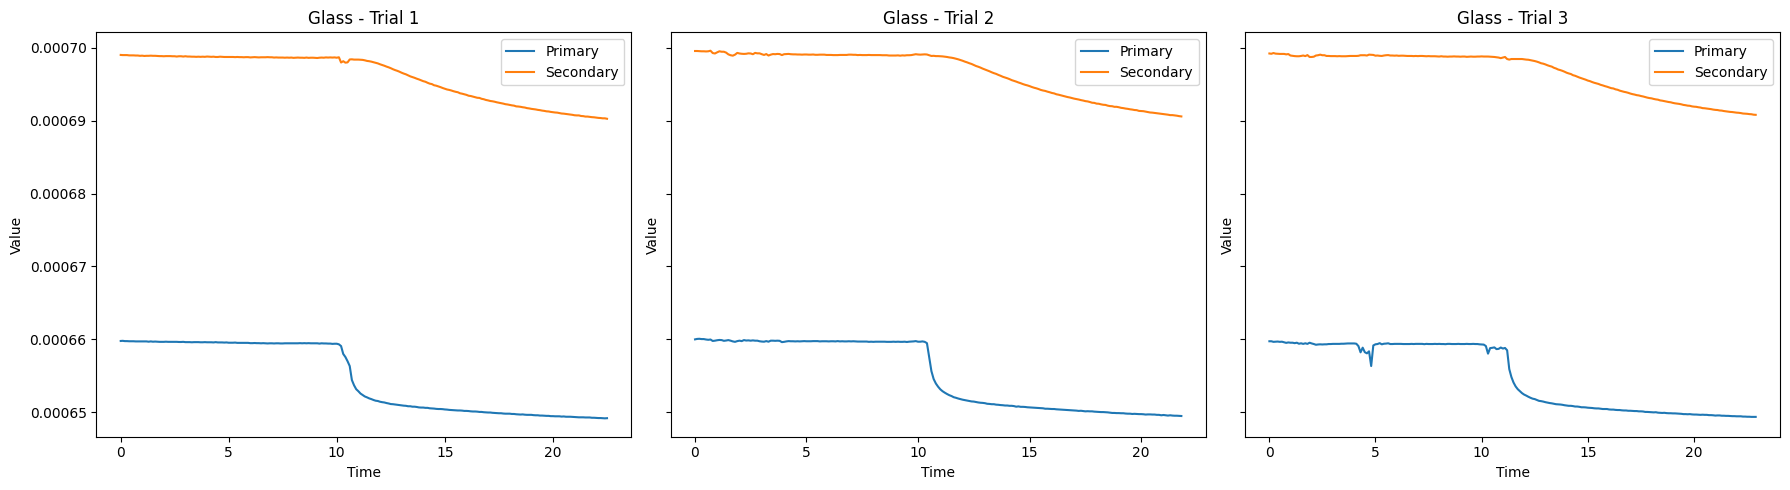

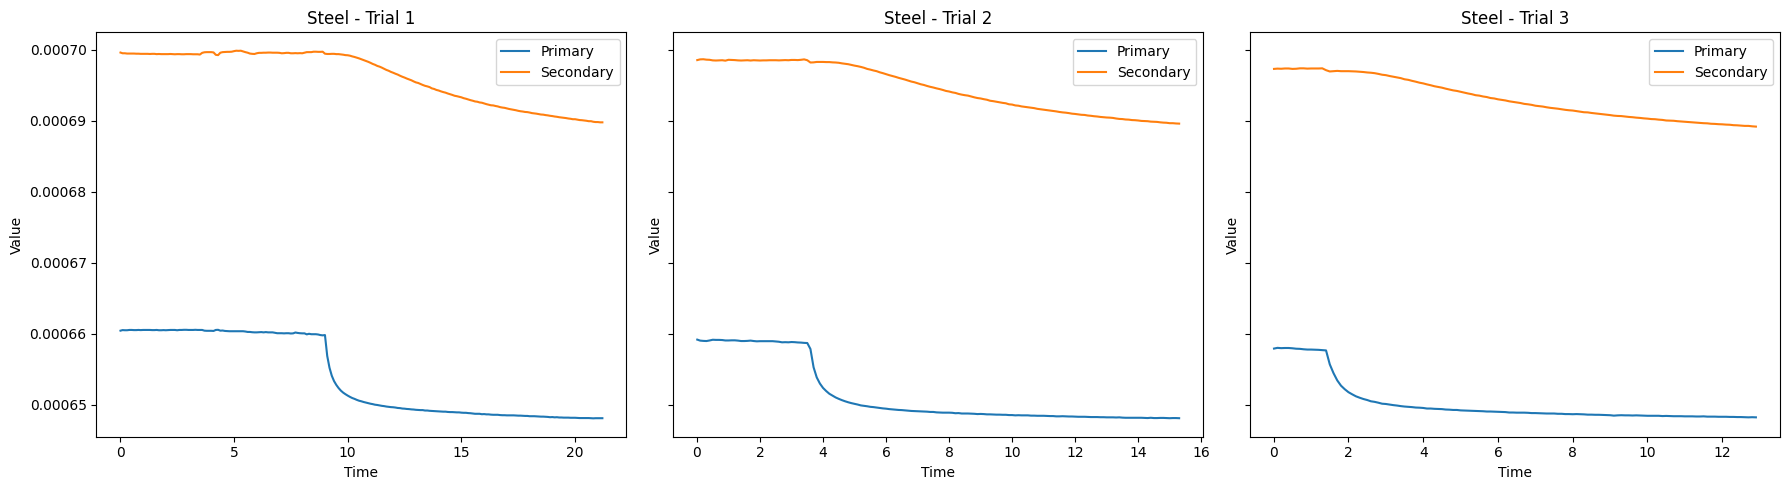

In [178]:
for m in materials:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        subset = data[(data['Sample'] == m) & (data['Trial'] == i+1)]

        ax.plot(subset['Time'].values, subset['Primary'], label='Primary')
        ax.plot(subset['Time'].values, subset['Secondary'], label='Secondary')

        ax.set_xlabel('Time')
        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i+1}')
        ax.legend()

    plt.tight_layout()
    plt.show()

## Plot Primary-Secondary Differnce

In [179]:
data['diff'] = data['Secondary'] - data['Primary']
data['abs_diff'] = data['diff'].abs()

# Plotting Primary and Secondary Readings Over Time
for m in materials:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        subset = data[(data['Sample'] == m) & (data['Trial'] == i+1)]

        ax.plot(subset['Time'].values, subset['diff'], label='Difference')
        ax.set_xlabel('Time')

        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i+1}')
        ax.legend()

    plt.tight_layout()
    plt.show()

# Elbow Finder

In [180]:
#Ask if this makes any differences
"""
def find_global_first_elbow(subset):
    time_col="Time"
    signal_col="Primary"
    smooth_window=15
    polyorder=2
    pre_search_window=30
    threshold_frac=0.15
    direction="drop"
"""

'\ndef find_global_first_elbow(subset):\n    time_col="Time"\n    signal_col="Primary"\n    smooth_window=15\n    polyorder=2\n    pre_search_window=30\n    threshold_frac=0.15\n    direction="drop"\n'

In [181]:
time_col="Time"
signal_col="Primary"
smooth_window=15

df = subset.sort_values(time_col)

t = df[time_col].to_numpy(dtype=float)
y = df[signal_col].to_numpy(dtype=float)

mask = np.isfinite(t) & np.isfinite(y)
t = t[mask]
y = y[mask]

n = len(y)

smooth_window = min(smooth_window, n - 1 if n % 2 == 0 else n)
smooth_window


15

In [182]:
def find_global_first_elbow(
    subset,
    time_col="Time",
    signal_col="Primary",
    smooth_window=15,
    polyorder=2,
    pre_search_window=30,
    threshold_frac=0.15,
    direction="drop"
):
    """
    Finds elbow by first locating the strongest global slope change,
    then searching backward to find the clean start of the elbow.
    """

    df = subset.sort_values(time_col)

    t = df[time_col].to_numpy(dtype=float)
    y = df[signal_col].to_numpy(dtype=float)

    mask = np.isfinite(t) & np.isfinite(y)
    t = t[mask]
    y = y[mask]

    n = len(y)

    if n < 10:
        return np.nan, np.nan, None

    # Make SavGol window valid
    smooth_window = min(smooth_window,n)

    if smooth_window % 2 == 0:
        smooth_window -= 1

    if smooth_window <= polyorder:
        smooth_window = polyorder + 3
        if smooth_window % 2 == 0:
            smooth_window += 1

    # Smooth signal
    y_smooth = savgol_filter(y, window_length=smooth_window, polyorder=polyorder)

    # Derivative
    dy = np.gradient(y_smooth, t)

    # Find strongest global slope
    if direction == "drop":
        peak_idx = np.argmin(dy)
        strongest_slope = dy[peak_idx]
        threshold = threshold_frac * strongest_slope  # negative value
        active = dy < threshold

    elif direction == "rise":
        peak_idx = np.argmax(dy)
        strongest_slope = dy[peak_idx]
        threshold = threshold_frac * strongest_slope
        active = dy > threshold

    else:
        raise ValueError("direction must be 'drop' or 'rise'")

    # Search backward from strongest slope to find start of elbow
    start_idx = peak_idx

    for j in range(peak_idx, 0, -1):
        if not active[j]:
            start_idx = j + 1
            break

    # Optional refinement: search only near the strongest slope region
    start_idx = max(0, start_idx)

    return t[start_idx], y[start_idx], start_idx

In [183]:
elbow_loc = {}
for m in materials:
    elbow_trials = {}
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        subset = data[(data['Sample'] == m) & (data['Trial'] == i+1)]
        subset = subset.sort_values('Time')

        elbow_time, elbow_value, elbow_idx = find_global_first_elbow(
            subset,
            time_col="Time",
            signal_col="Primary",
            smooth_window=15,
            polyorder=2,
            threshold_frac=0.3,
            direction="drop"
        )
        elbow_trials[i+1] = elbow_idx

        print(f"{m} - Trial {i+1} - {elbow_idx}")

        ax.plot(subset['Time'].values, subset['Primary'].values, label='Primary')
        ax.plot(subset['Time'].values, subset['Secondary'].values, label='Secondary')

        if not np.isnan(elbow_time):
            ax.axvline(elbow_time, linestyle=':', label='Primary elbow')
            ax.scatter(elbow_time, elbow_value)

            #ax.annotate(
            #    f"y={elbow_value:.6f}",
            #    xy=(elbow_time, elbow_value),
            #    xytext=(elbow_time, elbow_value + 0.000005),
            #    arrowprops=dict(arrowstyle="fancy"),
            #    fontsize=9
            #)

        ax.set_xlabel('Time')
        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i+1}')
        ax.legend()
    elbow_loc[m] = elbow_trials
    

    plt.tight_layout()
    plt.show()

glass - Trial 1 - 101
glass - Trial 2 - 101
glass - Trial 3 - 109


metal - Trial 1 - 30
metal - Trial 2 - 25
metal - Trial 3 - 56


steel - Trial 1 - 87
steel - Trial 2 - 33
steel - Trial 3 - 12


pdms - Trial 1 - 23
pdms - Trial 2 - 84
pdms - Trial 3 - 67


corkboard - Trial 1 - 81
corkboard - Trial 2 - 47
corkboard - Trial 3 - 2


/Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1317: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1319: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/Users/markkeanujamesexconde/Libra

In [184]:
elbow_loc['glass'][1] = 102
elbow_loc['glass'][2] = 105
elbow_loc['glass'][3] = 113

elbow_loc['metal'][1] = 33
elbow_loc['metal'][2] = 28
elbow_loc['metal'][3] = 60

elbow_loc['steel'][1] = 91
elbow_loc['steel'][2] = 37
elbow_loc['steel'][3] = 15

elbow_loc['pdms'][1] = 26
elbow_loc['pdms'][2] = 85
elbow_loc['pdms'][3] = 70


elbow_loc['corkboard'][1] = 84
elbow_loc['corkboard'][2] = 48
elbow_loc['corkboard'][3] = 57

for m, elbows in elbow_loc.items():

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for plot_idx, (i, elbow_idx) in enumerate(elbows.items()):
        ax = axes[plot_idx]

        subset = data[(data['Sample'] == m) & (data['Trial'] == i)].copy()
        subset = subset.sort_values('Time')

        elbow_time = subset.loc[subset['index'] == elbow_idx, 'Time'].values[0]
        elbow_value = subset.loc[subset['index'] == elbow_idx, 'Primary'].values[0]

        print(f"{m} - Trial {i} - {elbow_idx}")

        ax.plot(subset['Time'].values, subset['Primary'].values, label='Primary')
        ax.plot(subset['Time'].values, subset['Secondary'].values, label='Secondary')

        if not np.isnan(elbow_time):
            ax.axvline(elbow_time, linestyle='--', label='Primary elbow')
            ax.scatter(elbow_time, elbow_value, zorder=5)

            ax.annotate(
                f"y={elbow_value:.6f}",
                xy=(elbow_time, elbow_value),
                xytext=(elbow_time, elbow_value + 0.000005),
                #arrowprops=dict(arrowstyle="->"),
                fontsize=9
            )

        ax.set_xlabel('Time')
        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i}')
        ax.legend()
    
    plt.tight_layout()
    plt.show()

glass - Trial 1 - 102
glass - Trial 2 - 105
glass - Trial 3 - 113


metal - Trial 1 - 33
metal - Trial 2 - 28
metal - Trial 3 - 60


steel - Trial 1 - 91
steel - Trial 2 - 37
steel - Trial 3 - 15


pdms - Trial 1 - 26
pdms - Trial 2 - 85
pdms - Trial 3 - 70


corkboard - Trial 1 - 84
corkboard - Trial 2 - 48
corkboard - Trial 3 - 57


In [185]:
#data.loc

data["is_elbow"] = False
data["filter"] = False
    
for (sample, trial), subset in data.groupby(["Sample", "Trial"]):                                                                                           #Review for another day

    elbow_idx = elbow_loc[sample][trial]-10
    elbow_time = subset.loc[subset['index'] == elbow_idx, 'Time'].values[0]
    elbow_value = subset.loc[subset['index'] == elbow_idx, 'Primary'].values[0]

    print(f"{sample} - Trial {trial} - {elbow_idx}")

    data.loc[(data['Sample'] == sample) & (data['Trial'].astype(int) == int(trial)) & (data['index'] >= elbow_idx), 'filter'] = True
    data.loc[(data['Sample'] == sample) & (data['Trial'].astype(int) == int(trial)) & (data['index'] >= elbow_idx), 'elbow_time'] = elbow_time
    data.loc[(data['Sample'] == sample) & (data['Trial'].astype(int) == int(trial)) & (data['index'] >= elbow_idx), 'elbow_idx'] = elbow_idx

    if not np.isnan(elbow_time):
        # find the actual row in the original dataframe closest to the elbow time
        elbow_row_idx = subset["Time"].sub(elbow_time).abs().idxmin()                               #gets the last time-point

        data.loc[elbow_row_idx, "is_elbow"] = True
        data.loc[elbow_row_idx, "elbow_time"] = elbow_time
        data.loc[elbow_row_idx, "elbow_value"] = elbow_value

data = data[data['filter']]
data['Time'] = data['Time'] - data['elbow_time']
data['index'] = data['index'] - data['elbow_idx']
data = data[data['index'] < 50]

corkboard - Trial 1.0 - 74
corkboard - Trial 2.0 - 38
corkboard - Trial 3.0 - 47
glass - Trial 1.0 - 92
glass - Trial 2.0 - 95
glass - Trial 3.0 - 103
metal - Trial 1.0 - 23
metal - Trial 2.0 - 18
metal - Trial 3.0 - 50
pdms - Trial 1.0 - 16
pdms - Trial 2.0 - 75
pdms - Trial 3.0 - 60
steel - Trial 1.0 - 81
steel - Trial 2.0 - 27
steel - Trial 3.0 - 5


In [186]:
fig, axis = plt.subplots(3,1,figsize = (8,15))

for i, ax in enumerate(axis):

        for m in materials:
                
                subset = data[(data['Sample'] == m) & (data['Trial']==i+1)]
                ax.plot(subset['Time'].values, subset['Primary'].values, label=f"{m} - Primary")
                ax.plot(subset['Time'].values, subset['Secondary'].values, label=f"{m} - Secondary")

                ax.set_xlabel('Time (s)')
                ax.set_ylabel('Current (A)')
                ax.set_title(f"Trial {i+1}")
                ax.legend()

plt.tight_layout()
plt.show()
        


In [187]:
data = data[data['filter']]

for m in materials:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        subset = data[(data['Sample'] == m) & (data['Trial'] == i+1)]

        ax.plot(subset['Time'].values, subset['Primary'], label='Primary')
        ax.plot(subset['Time'].values, subset['Secondary'], label='Secondary')
        ax.set_xlabel('Time')

        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i+1}')
        ax.legend()

    plt.tight_layout()
    plt.show()

# Manual Extraction (new)

In [188]:
#new
def extract_trial_features(
    trial_data,
    analysis_window=(0.0, 5.0),
    initial_window=(0.0, 1.0),
    early_window=(0.0, 1.0),
    mid_window=(1.0, 3.0),
    late_window=(3.0, 5.0),
    smooth=True,
    savgol_window=11,
    savgol_polyorder=2,
):
    """
    Extract temperature-response and derivative-based features
    from one trial.

    Assumptions
    -----------
    - Columns:
        Time
        Primary
        Secondary
    - The first row corresponds to detected contact onset/elbow.
    - Primary and Secondary are already temperature values, or are
      linearly proportional to temperature.
    - Time is expressed in seconds.

    Returns
    -------
    pd.Series
        One row containing all extracted features.
    """

    # ------------------------------------------------------------
    # Helper functions
    # ------------------------------------------------------------

    def make_mask(time_array, window):
        start, end = window
        return (time_array >= start) & (time_array <= end)

    def fitted_slope(time_array, signal_array, window):
        """
        Fit y = slope*x + intercept within the selected window.
        """
        mask = make_mask(time_array, window)

        valid = (
            mask
            & np.isfinite(time_array)
            & np.isfinite(signal_array)
        )

        if valid.sum() < 3:
            return np.nan

        slope, _ = np.polyfit(
            time_array[valid],
            signal_array[valid],
            deg=1,
        )

        return float(slope)

    def mean_rate(time_array, signal_array, window):
        """
        Mean dT/dt over a window.

        Equivalent to:
            [T(t2) - T(t1)] / [t2 - t1]
        """
        start, end = window

        if end <= start:
            return np.nan

        if start < time_array.min() or end > time_array.max():
            return np.nan

        start_value = np.interp(
            start,
            time_array,
            signal_array,
        )

        end_value = np.interp(
            end,
            time_array,
            signal_array,
        )

        return float(
            (end_value - start_value)
            / (end - start)
        )

    def safe_ratio(numerator, denominator):
        if (
            not np.isfinite(numerator)
            or not np.isfinite(denominator)
            or np.isclose(denominator, 0.0)
        ):
            return np.nan

        return float(numerator / denominator)

    def estimate_rate_lag(
        time_array,
        primary_rate,
        secondary_rate,
        window,
    ):
        """
        Estimate the lag between Primary and Secondary derivative
        profiles using normalized cross-correlation.

        Positive lag:
            Secondary response occurs after Primary response.
        """
        mask = make_mask(time_array, window)

        t = time_array[mask]
        x = primary_rate[mask]
        y = secondary_rate[mask]

        valid = (
            np.isfinite(t)
            & np.isfinite(x)
            & np.isfinite(y)
        )

        t = t[valid]
        x = x[valid]
        y = y[valid]

        if len(t) < 4:
            return np.nan

        # Resample onto a uniform time grid because cross-correlation
        # assumes equally spaced observations.
        dt = np.median(np.diff(t))

        if not np.isfinite(dt) or dt <= 0:
            return np.nan

        uniform_time = np.arange(
            t[0],
            t[-1] + 0.5 * dt,
            dt,
        )

        x_uniform = np.interp(
            uniform_time,
            t,
            x,
        )

        y_uniform = np.interp(
            uniform_time,
            t,
            y,
        )

        # Remove the means and normalize.
        x_uniform = x_uniform - np.mean(x_uniform)
        y_uniform = y_uniform - np.mean(y_uniform)

        x_std = np.std(x_uniform)
        y_std = np.std(y_uniform)

        if np.isclose(x_std, 0.0) or np.isclose(y_std, 0.0):
            return np.nan

        x_uniform = x_uniform / x_std
        y_uniform = y_uniform / y_std

        correlation = correlate(
            y_uniform,
            x_uniform,
            mode="full",
        )

        lags = correlation_lags(
            len(y_uniform),
            len(x_uniform),
            mode="full",
        )

        best_lag_samples = lags[
            np.argmax(correlation)
        ]

        return float(best_lag_samples * dt)

    # ------------------------------------------------------------
    # 1. Clean and sort the trial
    # ------------------------------------------------------------

    required_columns = {
        "Time",
        "Primary",
        "Secondary",
    }

    missing_columns = (
        required_columns
        - set(trial_data.columns)
    )

    if missing_columns:
        raise KeyError(
            f"Missing columns: {sorted(missing_columns)}"
        )

    trial_data = (
        trial_data[
            ["Time", "Primary", "Secondary"]
        ]
        .copy()
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
        .sort_values("Time")
        .drop_duplicates(subset="Time")
        .reset_index(drop=True)
    )

    if len(trial_data) < 4:
        raise ValueError(
            "The trial contains too few valid observations."
        )

    original_time = trial_data[
        "Time"
    ].to_numpy(dtype=float)

    primary = trial_data[
        "Primary"
    ].to_numpy(dtype=float)

    secondary = trial_data[
        "Secondary"
    ].to_numpy(dtype=float)

    if np.any(np.diff(original_time) <= 0):
        raise ValueError(
            "Time must be strictly increasing."
        )

    # ------------------------------------------------------------
    # 2. Treat first observation as contact onset/elbow
    # ------------------------------------------------------------

    elbow_time = float(original_time[0])

    time = original_time - elbow_time

    # ------------------------------------------------------------
    # 3. Restrict every trial to the same fixed analysis window
    # ------------------------------------------------------------

    analysis_mask = make_mask(
        time,
        analysis_window,
    )

    time = time[analysis_mask]
    primary = primary[analysis_mask]
    secondary = secondary[analysis_mask]

    if len(time) < 4:
        raise ValueError(
            "Too few observations inside analysis_window."
        )

    # ------------------------------------------------------------
    # 4. Smooth the temperature signals before differentiation
    # ------------------------------------------------------------

    def smooth_signal(signal):
        if not smooth:
            return signal.copy()

        window = min(
            int(savgol_window),
            len(signal),
        )

        # Savitzky-Golay window must be odd.
        if window % 2 == 0:
            window -= 1

        minimum_window = savgol_polyorder + 2

        if minimum_window % 2 == 0:
            minimum_window += 1

        if window < minimum_window:
            return signal.copy()

        return savgol_filter(
            signal,
            window_length=window,
            polyorder=savgol_polyorder,
            mode="interp",
        )

    primary_smooth = smooth_signal(primary)
    secondary_smooth = smooth_signal(secondary)

    difference_smooth = (
        primary_smooth - secondary_smooth
    )

    # ------------------------------------------------------------
    # 5. Calculate full dT/dt profiles
    # ------------------------------------------------------------

    # np.gradient supports nonuniform time spacing.
    primary_rate = np.gradient(
        primary_smooth,
        time,
    )

    secondary_rate = np.gradient(
        secondary_smooth,
        time,
    )

    difference_rate = (
        primary_rate - secondary_rate
    )

    signals = {
        "primary": {
            "temperature": primary_smooth,
            "rate": primary_rate,
        },
        "secondary": {
            "temperature": secondary_smooth,
            "rate": secondary_rate,
        },
        "difference": {
            "temperature": difference_smooth,
            "rate": difference_rate,
        },
    }

    result = {
        "elbow_time": elbow_time,
        "analysis_start": analysis_window[0],
        "analysis_end": analysis_window[1],
    }

    # ------------------------------------------------------------
    # 6. Extract temperature and derivative features
    # ------------------------------------------------------------

    for name, values in signals.items():

        signal = values["temperature"]
        rate = values["rate"]

        baseline_value = float(signal[0])
        change = signal - baseline_value

        # --------------------------------------------------------
        # Temperature-response features
        # --------------------------------------------------------

        result[f"{name}_elbow_value"] = baseline_value

        # Since heating is sustained, use fixed-window endpoint
        # rather than "peak temperature."
        result[f"{name}_final_offset"] = float(
            change[-1]
        )

        result[f"{name}_response_auc"] = float(
            np.trapezoid(
                np.abs(change),
                time,
            )
        )

        # --------------------------------------------------------
        # Initial rate: fitted slope over initial_window
        # --------------------------------------------------------

        initial_rate = fitted_slope(
            time,
            signal,
            initial_window,
        )

        # Mean early rate:
        # [T(t2)-T(t1)] / [t2-t1]
        early_mean_rate = mean_rate(
            time,
            signal,
            early_window,
        )

        # Mid- and late-window fitted rates
        mid_rate = fitted_slope(
            time,
            signal,
            mid_window,
        )

        late_rate = fitted_slope(
            time,
            signal,
            late_window,
        )

        # --------------------------------------------------------
        # Maximum derivative and corresponding time
        # --------------------------------------------------------

        if np.all(np.isnan(rate)):
            max_rate = np.nan
            max_abs_rate = np.nan
            time_of_max_rate = np.nan
            time_of_max_abs_rate = np.nan

        else:
            max_rate_index = int(
                np.nanargmax(rate)
            )

            max_abs_rate_index = int(
                np.nanargmax(np.abs(rate))
            )

            max_rate = float(
                rate[max_rate_index]
            )

            max_abs_rate = float(
                np.abs(
                    rate[max_abs_rate_index]
                )
            )

            time_of_max_rate = float(
                time[max_rate_index]
            )

            time_of_max_abs_rate = float(
                time[max_abs_rate_index]
            )

        # --------------------------------------------------------
        # Rate-decay ratio
        # --------------------------------------------------------

        rate_decay_ratio = safe_ratio(
            late_rate,
            initial_rate,
        )

        # --------------------------------------------------------
        # Rate AUC
        # --------------------------------------------------------

        rate_auc = float(
            np.trapezoid(
                np.abs(rate),
                time,
            )
        )

        # For monotonic heating, the signed rate AUC should be
        # approximately equal to the final temperature change.
        signed_rate_auc = float(
            np.trapezoid(
                rate,
                time,
            )
        )

        # --------------------------------------------------------
        # Derivative variability
        # --------------------------------------------------------

        rate_std = (
            float(np.nanstd(rate, ddof=1))
            if len(rate) > 1
            else np.nan
        )

        # --------------------------------------------------------
        # Store results
        # --------------------------------------------------------

        result[f"{name}_initial_rate"] = initial_rate
        result[f"{name}_mean_early_rate"] = early_mean_rate
        result[f"{name}_mid_window_rate"] = mid_rate
        result[f"{name}_late_window_rate"] = late_rate

        result[f"{name}_max_rate"] = max_rate
        result[f"{name}_time_of_max_rate"] = (
            time_of_max_rate
        )

        result[f"{name}_max_abs_rate"] = max_abs_rate
        result[f"{name}_time_of_max_abs_rate"] = (
            time_of_max_abs_rate
        )

        result[f"{name}_rate_decay_ratio"] = (
            rate_decay_ratio
        )

        result[f"{name}_rate_auc"] = rate_auc
        result[f"{name}_signed_rate_auc"] = (
            signed_rate_auc
        )

        result[f"{name}_rate_std"] = rate_std

    # ------------------------------------------------------------
    # 7. Primary-secondary comparison features
    # ------------------------------------------------------------

    result["secondary_initial_rate_ratio"] = safe_ratio(
        result["secondary_initial_rate"],
        result["primary_initial_rate"],
    )

    result["secondary_mid_rate_ratio"] = safe_ratio(
        result["secondary_mid_window_rate"],
        result["primary_mid_window_rate"],
    )

    result["secondary_late_rate_ratio"] = safe_ratio(
        result["secondary_late_window_rate"],
        result["primary_late_window_rate"],
    )

    result["secondary_rate_auc_ratio"] = safe_ratio(
        result["secondary_rate_auc"],
        result["primary_rate_auc"],
    )

    # ------------------------------------------------------------
    # 8. Top-bottom rate-difference features
    # ------------------------------------------------------------

    result["mean_top_bottom_rate_difference"] = float(
        np.nanmean(difference_rate)
    )

    result["max_top_bottom_rate_difference"] = float(
        np.nanmax(difference_rate)
    )

    result["max_abs_top_bottom_rate_difference"] = float(
        np.nanmax(
            np.abs(difference_rate)
        )
    )

    result["top_bottom_rate_difference_auc"] = float(
        np.trapezoid(
            np.abs(difference_rate),
            time,
        )
    )

    result["top_bottom_rate_difference_std"] = float(
        np.nanstd(
            difference_rate,
            ddof=1,
        )
    )

    # ------------------------------------------------------------
    # 9. Lag between full Primary and Secondary rate profiles
    # ------------------------------------------------------------

    result["top_bottom_rate_lag"] = (
        estimate_rate_lag(
            time,
            primary_rate,
            secondary_rate,
            analysis_window,
        )
    )

    # ------------------------------------------------------------
    # 10. Return one feature row
    # ------------------------------------------------------------

    return pd.Series(result)

In [189]:
# 1. Define the new extract_trial_features function

# 2. Run this
features_df = (
    data
    .groupby(["Sample", "Trial"])
    .apply(
        lambda trial_data: extract_trial_features(
            trial_data,
            analysis_window=(0.0, 5.0),
            initial_window=(0.0, 1.0),
            early_window=(0.0, 1.0),
            mid_window=(1.0, 3.0),
            late_window=(3.0, 5.0),
        )
    )
    .reset_index()
)

# 3. View the extracted features
features_df.head()

,Sample,Trial,elbow_time,analysis_start,analysis_end,primary_elbow_value,primary_final_offset,primary_response_auc,primary_initial_rate,primary_mean_early_rate,...,secondary_initial_rate_ratio,secondary_mid_rate_ratio,secondary_late_rate_ratio,secondary_rate_auc_ratio,mean_top_bottom_rate_difference,max_top_bottom_rate_difference,max_abs_top_bottom_rate_difference,top_bottom_rate_difference_auc,top_bottom_rate_difference_std,top_bottom_rate_lag
0,corkboard,1.0,0.0,0.0,5.0,0.000660,-1.418881e-06,0.000004,-9.968069e-08,-1.768765e-07,...,-1.932072,0.244830,1.381788,0.769923,-1.554234e-07,2.529577e-07,0.000001,1.117889e-06,3.231100e-07,-0.2
1,corkboard,2.0,0.0,0.0,5.0,0.000660,-1.087413e-06,0.000003,-4.425664e-08,-1.086532e-07,...,6.468434,-0.193634,2.378904,0.975011,-6.453727e-08,1.056824e-06,0.000002,1.401718e-06,4.794175e-07,-0.3
2,corkboard,3.0,0.0,0.0,5.0,0.000659,-8.914685e-07,0.000003,-3.658796e-08,-7.473193e-08,...,5.110643,0.211770,2.166260,0.940917,-3.720462e-08,4.261891e-07,0.000001,8.856540e-07,3.266107e-07,-0.3
3,glass,1.0,0.0,0.0,5.0,0.000659,-8.820280e-06,0.000027,-2.325443e-08,-3.331922e-07,...,-0.053040,0.059943,3.087440,0.440789,-1.119637e-06,9.160839e-07,0.000010,8.855744e-06,3.093856e-06,1.6
4,glass,2.0,0.0,0.0,5.0,0.000660,-8.783776e-06,0.000030,-3.498881e-08,-1.180279e-06,...,-4.701613,0.186652,3.597143,0.405593,-1.051647e-06,1.064117e-06,0.000011,9.480761e-06,3.339320e-06,2.0


In [190]:
# ============================================================
# 1. Select the extracted features to visualize
# ============================================================

features = [
    # --------------------------------------------------------
    # Primary sensor
    # --------------------------------------------------------
    "primary_initial_rate",
    "primary_mean_early_rate",
    "primary_mid_window_rate",
    "primary_late_window_rate",
    "primary_max_rate",
    "primary_time_of_max_rate",
    "primary_rate_decay_ratio",
    "primary_rate_auc",
    "primary_rate_std",
    "primary_final_offset",
    "primary_response_auc",

    # --------------------------------------------------------
    # Secondary sensor
    # --------------------------------------------------------
    "secondary_initial_rate",
    "secondary_mean_early_rate",
    "secondary_mid_window_rate",
    "secondary_late_window_rate",
    "secondary_max_rate",
    "secondary_time_of_max_rate",
    "secondary_rate_decay_ratio",
    "secondary_rate_auc",
    "secondary_rate_std",
    "secondary_final_offset",
    "secondary_response_auc",

    # --------------------------------------------------------
    # Primary - Secondary difference
    # --------------------------------------------------------
    "difference_initial_rate",
    "difference_mean_early_rate",
    "difference_mid_window_rate",
    "difference_late_window_rate",
    "difference_max_rate",
    "difference_time_of_max_rate",
    "difference_rate_decay_ratio",
    "difference_rate_auc",
    "difference_rate_std",
    "difference_final_offset",
    "difference_response_auc",

    # --------------------------------------------------------
    # Secondary-to-primary ratios
    # --------------------------------------------------------
    "secondary_initial_rate_ratio",
    "secondary_mid_rate_ratio",
    "secondary_late_rate_ratio",
    "secondary_rate_auc_ratio",

    # --------------------------------------------------------
    # Cross-sensor derivative features
    # --------------------------------------------------------
    "mean_top_bottom_rate_difference",
    "max_top_bottom_rate_difference",
    "max_abs_top_bottom_rate_difference",
    "top_bottom_rate_difference_auc",
    "top_bottom_rate_difference_std",
    "top_bottom_rate_lag",
]


# Keep only features that actually exist in features_df.
# This prevents KeyError if some names were not generated.
features = [
    feature
    for feature in features
    if feature in features_df.columns
]

print(f"Number of features to plot: {len(features)}")

Number of features to plot: 43


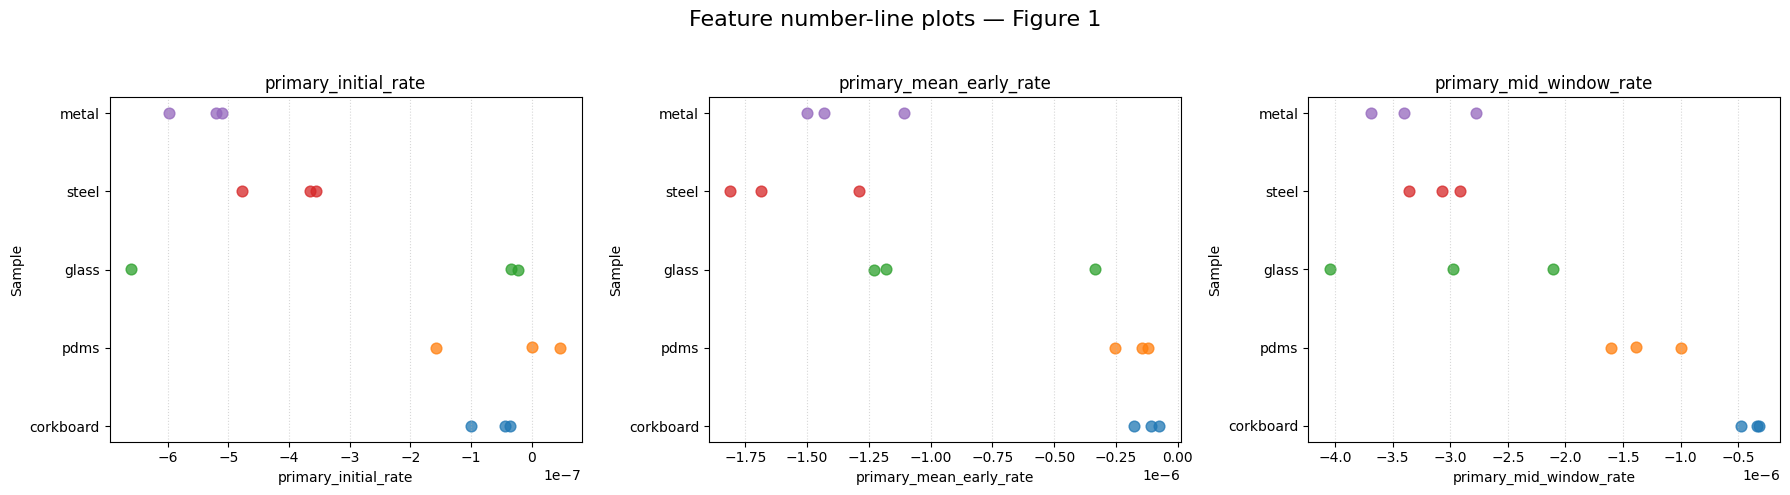

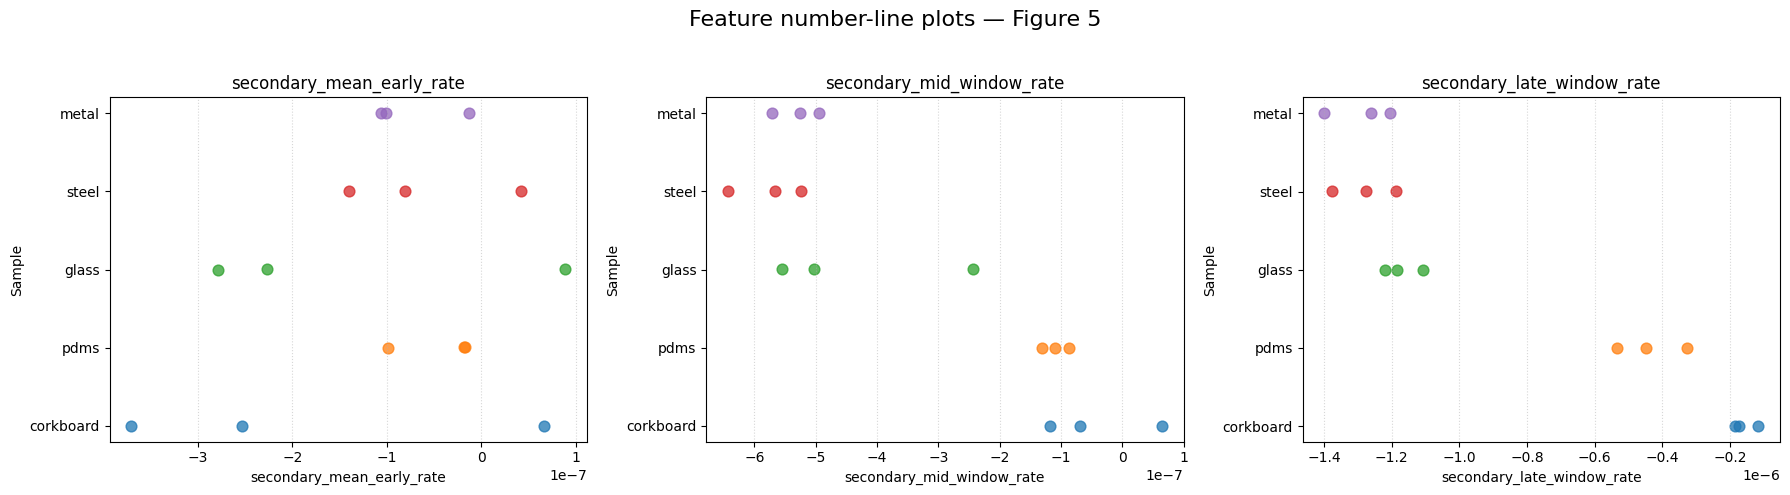

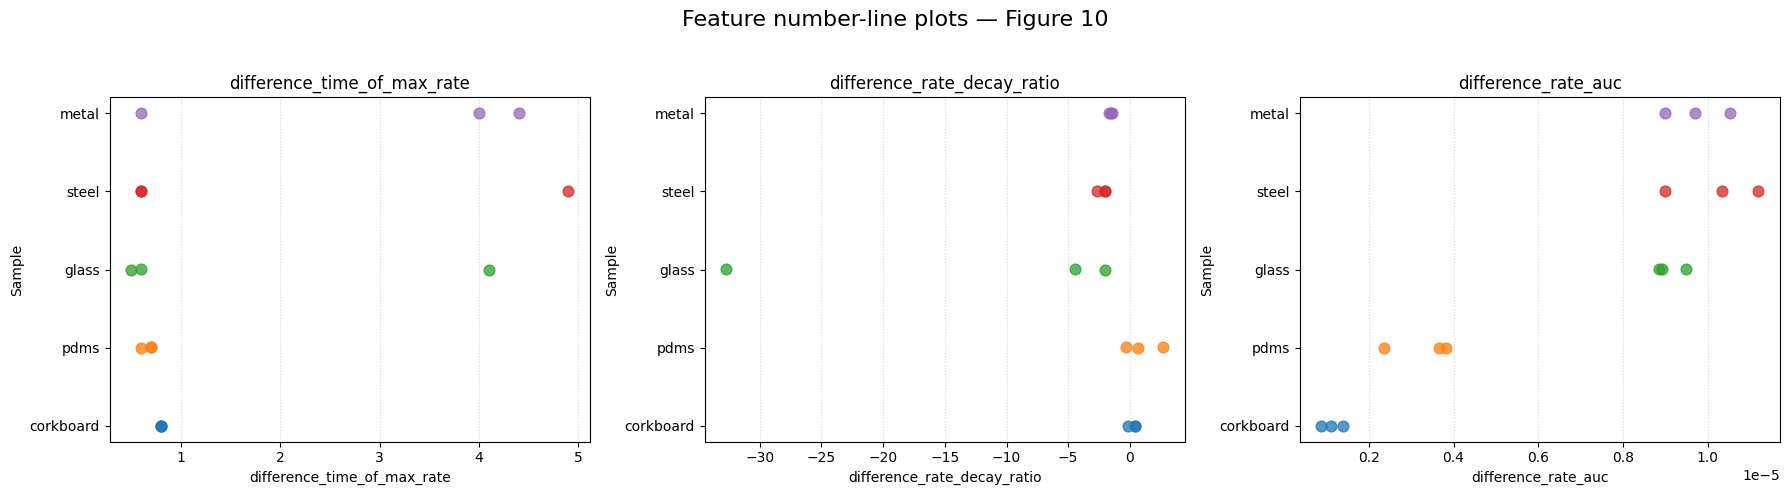

In [193]:
legend_col = "Sample"

plots_per_fig = 3
n_cols = 3
n_rows = 1

n_figures = math.ceil(
    len(features) / plots_per_fig
)

desired_order = [
    "corkboard",
    "pdms",
    "glass",
    "steel",
    "metal",
]

available_groups = (
    features_df[legend_col]
    .dropna()
    .unique()
)

groups = [
    group
    for group in desired_order
    if group in available_groups
]

# Include any samples not listed in desired_order
remaining_groups = [
    group
    for group in available_groups
    if group not in groups
]

groups.extend(remaining_groups)


for fig_num in range(n_figures):

    start = fig_num * plots_per_fig
    end = start + plots_per_fig

    current_features = features[start:end]

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 5),
    )

    axes = np.atleast_1d(axes).flatten()

    for ax, feature in zip(
        axes,
        current_features,
    ):

        for group_idx, group in enumerate(groups):

            subset = features_df[
                features_df[legend_col] == group
            ]

            values = pd.to_numeric(
                subset[feature],
                errors="coerce",
            ).dropna()

            if values.empty:
                continue

            y_position = np.full(
                len(values),
                group_idx,
                dtype=float,
            )

            # Small vertical jitter helps reveal overlapping trials
            jitter = np.random.uniform(
                0,
                0.005,
                size=len(values),
            )

            ax.scatter(
                values,
                y_position + jitter,
                label=str(group),
                alpha=0.75,
                s=60,
            )

        ax.set_yticks(
            range(len(groups))
        )

        ax.set_yticklabels(groups)

        ax.set_xlabel(feature)
        ax.set_ylabel(legend_col)
        ax.set_title(feature)

        ax.grid(
            axis="x",
            linestyle=":",
            alpha=0.5,
        )

    # Hide unused axes in the final figure
    for ax in axes[len(current_features):]:
        ax.axis("off")

    fig.suptitle(
        (
            "Feature number-line plots — "
            f"Figure {fig_num + 1}"
        ),
        fontsize=16,
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.95]
    )

    plt.show()

# Manual Extraction (old)

In [ ]:
#old
def extract_trial_features(trial_data, slope_window=1.0):

    # 1. Sort the trial by time
    trial_data = trial_data.sort_values("Time").copy()

    # 2. Convert DataFrame columns to NumPy arrays
    original_time = trial_data["Time"].to_numpy(dtype=float)
    primary = trial_data["Primary"].to_numpy(dtype=float)
    secondary = trial_data["Secondary"].to_numpy(dtype=float)

    # 3. First point is treated as the elbow
    elbow_time = original_time[0]

    # Shift time so the elbow becomes t = 0
    time = original_time - elbow_time

    # 4. Create the three signals to analyze
    signals = {
        "primary": primary,
        "secondary": secondary,
        "difference": primary - secondary
    }

    # Store all calculated features here
    result = {
        "elbow_time": elbow_time
    }

    # 5. Calculate the same features for each signal
    for name, signal in signals.items():

        # Signal value at the elbow
        elbow_value = signal[0]

        # Signal change relative to the elbow
        change = signal - elbow_value

        # Absolute distance from the elbow baseline
        abs_change = np.abs(change)

        # ----------------------------------------
        # Initial slope
        # ----------------------------------------

        slope_mask = (
            (time <= 3)
            & (time >= slope_window)
        )

        if slope_mask.sum() >= 3:
            x = time[slope_mask]
            y = change[slope_mask]

            denominator = np.sum(x**2)

            if denominator != 0:
                slope = np.sum(x * y) / denominator
            else:
                slope = np.nan
        else:
            slope = np.nan

        # ----------------------------------------
        # Peak response
        # ----------------------------------------

        if np.all(np.isnan(abs_change)):
            peak_change = np.nan
            peak_time = np.nan
        else:
            peak_idx = np.nanargmax(abs_change)
            peak_change = abs_change[peak_idx]
            peak_time = time[peak_idx]

        # ----------------------------------------
        # Area under the response curve
        # ----------------------------------------

        auc = np.trapezoid(abs_change, time)

        # ----------------------------------------
        # Final signal offset
        # ----------------------------------------

        final_offset = change[-1]

        # Store features using dynamic column names
        result[f"{name}_elbow_value"] = elbow_value
        result[f"{name}_slope"] = slope
        result[f"{name}_peak_change"] = peak_change
        result[f"{name}_peak_time"] = peak_time
        result[f"{name}_auc"] = auc
        result[f"{name}_final_offset"] = final_offset

    # 6. Compare Secondary against Primary
    primary_peak = result["primary_peak_change"]
    primary_auc = result["primary_auc"]
    primary_slope = result["primary_slope"]

    result["secondary_peak_ratio"] = (
        result["secondary_peak_change"] / primary_peak
        if primary_peak != 0
        else np.nan
    )

    result["secondary_auc_ratio"] = (
        result["secondary_auc"] / primary_auc
        if primary_auc != 0
        else np.nan
    )

    result["secondary_slope_ratio"] = (
        result["secondary_slope"] / primary_slope
        if primary_slope != 0
        else np.nan
    )

    # 7. Secondary peak time minus Primary peak time
    result["lag"] = (
        result["secondary_peak_time"]
        - result["primary_peak_time"]
    )

    # 8. Convert the dictionary into one pandas row
    return pd.Series(result)

features_df = (
    data
    .groupby(["Sample", "Trial"])
    .apply(extract_trial_features)
    .reset_index()
)

In [ ]:
features = [
    # Primary
    "primary_slope",
    "primary_peak_change",
    #"primary_peak_time",
    "primary_auc",


    # Secondary
    "secondary_slope",
    "secondary_peak_change",
    #"secondary_peak_time",
    "secondary_auc",


    # Difference: Primary - Secondary
    "difference_slope",
    "difference_peak_change",
    #"difference_peak_time",
    "difference_auc",


    # Ratios and timing
    "secondary_peak_ratio",
    "secondary_auc_ratio",
    "secondary_slope_ratio",
    "lag"
]

#legend_col = 'Sample'

#features_df = features_df[features_df['Sample'] != 'steel']

In [ ]:
legend_col = "Sample"

# Automatically select numeric features,
# excluding identifiers and elbow_time
excluded_cols = ["Sample", "Trial", "elbow_time"]

plots_per_fig = 3
n_cols = 3
n_rows = 1

n_figures = math.ceil(len(features) / plots_per_fig)

desired_order = [
    "corkboard",
    "pdms",
    "glass",
    "steel",
    "metal"
]

available_groups = features_df[legend_col].dropna().unique()

groups = [
    group
    for group in desired_order
    if group in available_groups
]

# Keep the same sample order in every subplot
#groups = features_df[legend_col].dropna().unique()

for fig_num in range(n_figures):

    start = fig_num * plots_per_fig
    end = start + plots_per_fig
    current_features = features[start:end]

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 5)
    )

    axes = axes.flatten()

    for ax, feature in zip(axes, current_features):

        for group_idx, group in enumerate(groups):

            subset = features_df[
                features_df[legend_col] == group
            ]

            # Convert to numeric and remove NaN values
            values = pd.to_numeric(
                subset[feature],
                errors="coerce"
            ).dropna()

            # Place every sample on its own horizontal level
            y_position = np.full(
                len(values),
                group_idx
            )

            ax.scatter(
                values,
                y_position,
                label=str(group),
                alpha=0.75,
                s=60
            )

        ax.set_yticks(range(len(groups)))
        ax.set_yticklabels(groups)

        ax.set_xlabel(feature)
        ax.set_ylabel(legend_col)
        ax.set_title(feature)

        ax.grid(
            axis="x",
            linestyle=":",
            alpha=0.5
        )

    # Hide unused plots in the final figure
    for ax in axes[len(current_features):]:
        ax.axis("off")

    fig.suptitle(
        f"Feature number-line plots — Figure {fig_num + 1}",
        fontsize=16
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [ ]:
# Example:
legend_col = ['Sample','Trial','elbow_time']

# Keep only numeric feature columns and exclude the legend column
#features = [
#    col for col in features_df.select_dtypes(include=np.number).columns
#    if col not in legend_col
#]

# Generate all unique feature pairs
pairs = list(itertools.combinations(features, 2))

plots_per_fig = 9
n_cols = 3
n_rows = 3

n_figures = math.ceil(len(pairs) / plots_per_fig)

for fig_num in range(n_figures):

    start = fig_num * plots_per_fig
    end = start + plots_per_fig
    current_pairs = pairs[start:end]

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 15)
    )

    axes = axes.flatten()

    for ax, (x_col, y_col) in zip(axes, current_pairs):

        for group, subset in features_df.groupby('Sample'):

            # Remove rows with missing x or y values
            valid_subset = subset[[x_col, y_col]].dropna()

            ax.scatter(
                valid_subset[x_col],
                valid_subset[y_col],
                label=str(group),
                alpha=0.7
            )

        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f"{x_col} vs {y_col}")

        ax.legend(
            #title=legend_col,
            fontsize=8,
            title_fontsize=9,
            loc="best"
        )

    # Hide unused subplots in the final figure
    for ax in axes[len(current_pairs):]:
        ax.axis("off")

    fig.suptitle(
        f"Scatter Plot Combinations — Figure {fig_num + 1}",
        fontsize=16
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

## Principal Component Analysis

In [ ]:
features_df = features_df.dropna(axis = 1)
X = features_df[features]
y = features_df["Sample"]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))

for m in features_df['Sample'].unique():
    mask = y == m
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Thermal Response Features")
plt.legend()
plt.tight_layout()
plt.show()

print(pca.explained_variance_ratio_)

In [ ]:
features_df = features_df.dropna(axis = 1)
X = features_df[features_df.columns[6:]]
y = features_df["Sample"]


X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))

for m in features_df['Sample'].unique():
    mask = y == m
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Thermal Response Features")
plt.legend()
plt.tight_layout()
plt.show()

print(pca.explained_variance_ratio_)

## Cumulative Variance Explained

In [ ]:
# explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

x = range(1, len(explained_variance) + 1)

explained_percent = explained_variance * 100
cumulative_percent = cumulative_variance * 100

plt.figure(figsize=(10, 5))

bars = plt.bar(
    x,
    explained_percent,
    alpha=0.5,
    label="Individual explained variance"
)

plt.plot(
    x,
    cumulative_percent,
    marker="o",
    label="Cumulative explained variance"
)

# label individual explained variance bars
for i, value in enumerate(explained_percent, start=1):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

# label cumulative explained variance points
for i, value in enumerate(cumulative_percent, start=1):
    plt.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xlabel("Principal component")
plt.ylabel("Explained variance (%)")
plt.title("PCA Explained Variance")
plt.xticks(x)
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()

# `tsfresh` Feature Extraction

In [ ]:
# organized tsfresh settings
_basic = [
    "mean", "median", "minimum", "maximum", "absolute_maximum"
]

_variability = [
    "standard_deviation", "variance", "root_mean_square",
    "mean_abs_change", "mean_change"
]

_distribution = ["skewness", "kurtosis"]
_energy = ["abs_energy", "sum_values"]
_counts = ["count_above_mean", "count_below_mean"]
_strikes = ["longest_strike_above_mean", "longest_strike_below_mean"]

_linear_trend = [{"attr": a} for a in ("slope", "intercept", "rvalue", "pvalue", "stderr")]
_autocorr = [{"lag": l} for l in (1, 2, 5, 10)]
_change_quantiles = [
    {"ql": 0.0, "qh": 0.2, "isabs": False, "f_agg": "mean"},
    {"ql": 0.0, "qh": 0.2, "isabs": True,  "f_agg": "mean"},
    {"ql": 0.8, "qh": 1.0, "isabs": False, "f_agg": "mean"},
    {"ql": 0.8, "qh": 1.0, "isabs": True,  "f_agg": "mean"},
]
_cid_ce = [{"normalize": True}, {"normalize": False}]

settings = {k: None for k in (_basic + _variability + _distribution + _energy + _counts + _strikes)}
settings.upDATE({
    "linear_trend": _linear_trend,
    "autocorrelation": _autocorr,
    "change_quantiles": _change_quantiles,
    "cid_ce": _cid_ce,
})


In [ ]:
# use only filtered data
ts_data = data[(data["filter"])]

# create one ID per material-trial
ts_data["id"] = (
    ts_data["Sample"].astype(str) +
    "_trial_" +
    ts_data["Trial"].astype(int).astype(str)
)

# primary sensor table
primary = ts_data[[
    "id",
    "Time",
    "Primary"
]].copy()

primary = primary.rename(columns={
    "Time": "time",
    "Primary": "value"
})

primary["kind"] = "Primary"

# secondary sensor table
secondary = ts_data[[
    "id",
    "Time",
    "Secondary"
]].copy()

secondary = secondary.rename(columns={
    "Time": "time",
    "Secondary": "value"
})

secondary["kind"] = "Secondary"


# diff sensor table
diff = ts_data[[
    "id",
    "Time",
    "diff"
]].copy()

diff = diff.rename(columns={
    "Time": "time",
    "diff": "value"
})

diff["kind"] = "Difference"

# combine primary and secondary
tsfresh_input = pd.concat(
    [primary, secondary, diff],
    ignore_index=True
)

tsfresh_input = tsfresh_input[[
    "id",
    "time",
    "kind",
    "value"
]]

# clean invalid values
tsfresh_input = tsfresh_input.replace([np.inf, -np.inf], np.nan)
tsfresh_input = tsfresh_input.dropna()

tsfresh_input.head()

In [ ]:
tsfresh_features = extract_features(
    tsfresh_input,
    column_id="id",
    column_sort="time",
    column_kind="kind",
    column_value="value",
    default_fc_parameters=settings,
    n_jobs=0
)

In [ ]:
labels = (
    ts_data[["id", "Sample", "Trial"]]
    .drop_duplicates()
    .set_index("id")
)
tsfresh_features = tsfresh_features.dropna(axis=1)


tsfresh_features = tsfresh_features.join(labels)
tsfresh_features = tsfresh_features.reset_index()
tsfresh_features.head()

In [ ]:
tsfresh_features.columns

In [ ]:
# -index ; - trial

legend_col = "Sample"

# Automatically select numeric features,
# excluding identifiers and elbow_time
excluded_cols = ["Sample", "Trial", "index"]

features = [
    col
    for col in tsfresh_features.select_dtypes(include=np.number).columns
    if col not in excluded_cols
]

plots_per_fig = 9
n_cols = 3
n_rows = 3

n_figures = math.ceil(len(features) / plots_per_fig)

# Keep the same sample order in every subplot
groups = tsfresh_features[legend_col].dropna().unique()

for fig_num in range(n_figures):

    start = fig_num * plots_per_fig
    end = start + plots_per_fig
    current_features = features[start:end]

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 15)
    )

    axes = axes.flatten()

    for ax, feature in zip(axes, current_features):

        for group_idx, group in enumerate(groups):

            subset = tsfresh_features[
                tsfresh_features[legend_col] == group
            ]

            # Convert to numeric and remove NaN values
            values = pd.to_numeric(
                subset[feature],
                errors="coerce"
            ).dropna()

            # Place every sample on its own horizontal level
            y_position = np.full(
                len(values),
                group_idx
            )

            ax.scatter(
                values,
                y_position,
                label=str(group),
                alpha=0.75,
                s=60
            )

        ax.set_yticks(range(len(groups)))
        ax.set_yticklabels(groups)

        ax.set_xlabel(feature)
        ax.set_ylabel(legend_col)
        ax.set_title(feature)

        ax.grid(
            axis="x",
            linestyle=":",
            alpha=0.5
        )

    # Hide unused plots in the final figure
    for ax in axes[len(current_features):]:
        ax.axis("off")

    fig.suptitle(
        f"Feature number-line plots — Figure {fig_num + 1}",
        fontsize=16
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

## Principal Component Analysis

In [ ]:
feature_cols = tsfresh_features.drop(columns=["index", "Sample", "Trial"]).columns
feature_cols = [c for c in feature_cols if 'Difference' not in c]

X = tsfresh_features[feature_cols]
y = tsfresh_features["Sample"]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))

for m in y.unique():
    mask = y == m
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of tsfresh Features")
plt.legend()
plt.tight_layout()
plt.show()

print(pca.explained_variance_ratio_)

## Cumulative Variance Explained

In [ ]:
# explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

x = range(1, len(explained_variance) + 1)

explained_percent = explained_variance * 100
cumulative_percent = cumulative_variance * 100

plt.figure(figsize=(10, 5))

bars = plt.bar(
    x,
    explained_percent,
    alpha=0.5,
    label="Individual explained variance"
)

plt.plot(
    x,
    cumulative_percent,
    marker="o",
    label="Cumulative explained variance"
)

# label individual explained variance bars
for i, value in enumerate(explained_percent, start=1):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

# label cumulative explained variance points
for i, value in enumerate(cumulative_percent, start=1):
    plt.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xlabel("Principal component")
plt.ylabel("Explained variance (%)")
plt.title("PCA Explained Variance")
plt.xticks(x)
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()

# Reservoir Computing

In [ ]:
rc_data = data[(data["filter"]) & (data['Sample'] != 'steel')].copy()
rc_data = rc_data.sort_values(["Sample", "Trial", "Time"])

length_check = (
    rc_data
    .groupby(["Sample", "Trial"])
    .size()
    .reset_index(name="n_points")
)

min_len = length_check["n_points"].min()

X_list = []
y_list = []

for (sample, trial), subset in rc_data.groupby(["Sample", "Trial"]):

    subset = subset.sort_values("Time").head(min_len)

    sequence = subset[[
        "Primary",
        "Secondary"
    ]].values

    X_list.append(sequence)
    y_list.append(sample)

X = X_list
y = np.array(y_list)

print(len(X))
print(X[0].shape)
print(y.shape)


le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(le.classes_)
print(y_encoded)

In [ ]:
X_rc = []

for sequence in X:

    reservoir = Reservoir(
        units=50,
        sr=0.9,
        lr=0.3,
        input_scaling=0.5,
        seed=42
    )

    states = reservoir.run(sequence)

    features = np.concatenate([
        states.mean(axis=0),
        states.std(axis=0),
        states[-1, :]
    ])

    X_rc.append(features)

X_rc = np.array(X_rc)

print(X_rc.shape)

## Principal Component Analysis

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rc)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

materials = np.unique(y)

plt.figure(figsize=(8, 6))

for m in materials:
    mask = y == m

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m,
        s=60
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Reservoir Computing Features")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

x = range(1, len(explained_variance) + 1)

explained_percent = explained_variance * 100
cumulative_percent = cumulative_variance * 100

plt.figure(figsize=(10, 5))

bars = plt.bar(
    x,
    explained_percent,
    alpha=0.5,
    label="Individual explained variance"
)

plt.plot(
    x,
    cumulative_percent,
    marker="o",
    label="Cumulative explained variance"
)

# label individual explained variance bars
for i, value in enumerate(explained_percent, start=1):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

# label cumulative explained variance points
for i, value in enumerate(cumulative_percent, start=1):
    plt.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xlabel("Principal component")
plt.ylabel("Explained variance (%)")
plt.title("PCA Explained Variance")
plt.xticks(x)
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()